In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on sys.path so 'backtester' imports work
cwd = Path(os.getcwd())
candidates = [cwd, cwd.parent, Path("..").resolve()]
for p in candidates:
    if (p / "backtester").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

print("PYTHONPATH set. Using root:", sys.path[0])

PYTHONPATH set. Using root: c:\Users\User\Desktop\Crypto strategy backtest


## Load Data

In [2]:
import pandas as pd

def load_crypto_parquet_data(coin_name: str, timeframe: str = "5m", nM: int = 54, section: str = "UTC") -> pd.DataFrame:
    df = pd.read_parquet(fr'C:\Users\User\Desktop\Crypto\{coin_name}_{timeframe}_{nM}M_{section}.parquet')
    return df
def generate_us_session_bars_info(df, include_holidays: bool = False):
    # 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df
def generate_allday_bars_info(df, include_holidays: bool = True):
# 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['time'] = df['dt_ny'].dt.time
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df


In [3]:
coin_name = 'ETH'  # 可更改為 'ETH', 'SOL', 'BTC', 'ADA', 'PAXG' 等等
nM = 48
timeframe = "5m"
section = "UTC"

df = load_crypto_parquet_data(coin_name=coin_name, timeframe=timeframe, nM=nM, section=section)
df = generate_allday_bars_info(df, include_holidays=False)


## Split Data

In [4]:
# 分成n等分windows
def split_into_windows(df: pd.DataFrame, n_windows: int, overlap_ratio: float = 0.0) -> list[pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    window_size = n_dates // n_windows
    windows = []
    end_idx = 0
    total_windows = (n_dates - window_size)//(int(window_size * (1 - overlap_ratio))) + 1 if overlap_ratio > 0 else n_windows
    for i in range(total_windows):
        start_idx = end_idx
        if i == total_windows - 1:  # 最後一個視窗包含剩餘的日期
            end_idx = n_dates
        if overlap_ratio > 0 and i > 0:
            overlap_size = int(window_size * overlap_ratio)
            start_idx -= overlap_size
        end_idx = start_idx + window_size
        window_dates = unique_dates[start_idx:end_idx]
        window_df = df[df.index.isin(window_dates)].copy()
        windows.append(window_df)
    return windows
def split_into_train_test(df: pd.DataFrame, train_pct: float = 0.7) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    train_size = int(n_dates * train_pct)
    train_dates = unique_dates[:train_size]
    test_dates = unique_dates[train_size:]
    train_df = df[df.index.isin(train_dates)].copy()
    test_df = df[df.index.isin(test_dates)].copy()
    return train_df, test_df

In [54]:
splited_dfs = split_into_windows(df, n_windows=20, overlap_ratio=0)
splited_train_test_dfs = [split_into_train_test(window_df, train_pct=0.7) for window_df in splited_dfs]

## Build Strategy

In [6]:
from backtester.models import Position, Side, ActionType, BacktestConfig, SizingEquityBase
from backtester.engine import BacktestEngine
from backtester.strategy_base import StrategyContext
from backtester.strategies.al_breakout_pullback_50pct import ALBreakoutPullback50pctParams, ALBreakoutPullback50pctStrategy
from typing import Any, Dict, List
from itertools import product
def build_param_combinations(grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """
    將 param_grid 展開成所有組合，每個組合是一個 dict。
    grid 的值必須是 list/tuple 等 iterable。
    """
    keys = list(grid.keys())
    values_lists = [grid[k] for k in keys]
    combos = [dict(zip(keys, vals)) for vals in product(*values_lists)]
    return combos
def tune_strategy_params(train_df: pd.DataFrame, test_df: pd.DataFrame, param_grid: dict, best_n_params: int, engine) -> dict:
    best_params = None
    best_performance = -float('inf')
    params_combinations = build_param_combinations(param_grid)
        
    performance_list = []

    for params in params_combinations:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        train_result = engine.run(train_df, strat)
        performance = train_result.equity_curve.values[-1] - train_result.equity_curve.values[0]  # 總收益作為績效指標
        unique_days = train_df.index.normalize().unique()
        performance_per_day = performance / (len(unique_days))

        if performance_per_day > best_performance:
            best_performance = performance_per_day
        performance_list.append((params, performance_per_day, len(train_result.trades)))
    performance_list.sort(key=lambda x: x[1], reverse=True)
    best_params_list = performance_list[:best_n_params]

    train_vs_test_results = []
    for params, perf, n_trades in best_params_list:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        test_result = engine.run(test_df, strat)
        test_performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
        unique_days = test_df.index.normalize().unique()
        test_performance_per_day = test_performance / (len(unique_days))
        perf_diff = test_performance_per_day - perf
        print(f"Params: {params}, Train Perf/Day: {perf}, Test Perf/Day: {test_performance_per_day}, Trades: {len(test_result.trades)}, Perf Diff: {perf_diff}")
        train_vs_test_results.append((params, perf, test_performance_per_day, perf_diff))

    return train_vs_test_results
def test_strategy_with_params(test_df: pd.DataFrame, params: dict, engine) -> Any:
    strat_params = ALBreakoutPullback50pctParams(**params)
    strat = ALBreakoutPullback50pctStrategy(strat_params)
    test_result = engine.run(test_df, strat)
    performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
    unique_days = test_df.index.normalize().unique()
    performance_per_day = performance / (len(unique_days))
    return performance_per_day, test_result


In [7]:
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0004, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)

In [8]:
for param, values in ALBreakoutPullback50pctParams.__annotations__.items():
      print(f"Parameter: {param} | Type: {values}")  # 查看可調參數

Parameter: break_out_series_n | Type: int
Parameter: break_out_n_bars | Type: int
Parameter: BO_n_times_atr | Type: float
Parameter: n_bar_pivot | Type: int
Parameter: pullback_ratio | Type: float
Parameter: max_notional_pct | Type: float
Parameter: min_qty | Type: float
Parameter: sl_atr_like | Type: float
Parameter: fixed_sl_pct | Type: float
Parameter: rr | Type: float
Parameter: time_exit_bars | Type: int
Parameter: allow_side | Type: Optional[Side]
Parameter: sizing_equity_base | Type: SizingEquityBase


In [9]:

# param_grid = {
#     'rr': [0.3, 0.5, 0.7],
#     'break_out_n_bars': [10, 20, 30],
#     'break_out_series_n': [3],
#     'BO_n_times_atr': [0.5, 1.0, 1.5, 2],
# }
param_grid = {
    'rr': [1.5],
    'break_out_n_bars': [4],
    'break_out_series_n': [10],
    'BO_n_times_atr': [2],
}
best_n_params = 2
best_params_list = []
start_window = 0
for i in range(start_window, len(splited_train_test_dfs)):
    print(f"=== Window {i+1} ===")
    best_params =  tune_strategy_params(
        train_df=splited_train_test_dfs[i][0],
        test_df=splited_train_test_dfs[i][1],
        param_grid=param_grid,
        best_n_params=best_n_params,
        engine=engine
    )
    # print("Best Params:")
    for params, perf, test_perf, perf_diff in best_params:
        pass
        # print(f"Params: {params}, Performance per day: {perf}, Test Performance per day: {test_perf}, Performance Difference: {perf_diff}")
    best_params_list.append(best_params)



=== Window 1 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.05418967042391912, Test Perf/Day: 0.011717687291206242, Trades: 2, Perf Diff: -0.04247198313271287
=== Window 2 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: -0.27586849576420364, Test Perf/Day: 0.33371687357798996, Trades: 2, Perf Diff: 0.6095853693421935
=== Window 3 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.6391200281603902, Test Perf/Day: 0.0, Trades: 0, Perf Diff: -0.6391200281603902
=== Window 4 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.34363348693314666, Test Perf/Day: -4.231582504556402, Trades: 4, Perf Diff: -4.575215991489549
=== Window 5 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: -

In [10]:
for i in range(start_window, len(splited_train_test_dfs)):
    print(f"=== Window {i+1} Test Results ===")
    for params, train_perf, _ in best_params_list[i-start_window]:
        test_perf, test_result = test_strategy_with_params(
            test_df=splited_train_test_dfs[i][1],
            params=params,
            engine=engine
        ) 
        print(f"Test Result with Params: {params}, performance per day: {test_perf}, Trades: {len(test_result.trades)} , performance diff: {test_perf - train_perf}")

=== Window 1 Test Results ===


ValueError: too many values to unpack (expected 3)

## analytics

0.000125
=== Fee Rate: 0.013% ===
trades: 1724
win_rate: 0.5365429234338747
profit_factor: 1.1561400152565298
sharpe_ratio: 1.1613951945194665
max_drawdown: -0.1713927701141889
mean_pnl_pct: 0.0007407939306296478
median_pnl_pct: 0.0071794355023178606
p10_pnl_pct: -0.010710433324239781
p90_pnl_pct: 0.010976627849663396
final profit: 15547.213652202317
   entry_time_hour        pnl                                           
                         mean          sum         max         min count
0                2  13.791630  3089.325117  322.485094 -352.356767   224
1                3 -26.948219 -2506.184340  348.330728 -309.539219    93
2                4  -2.254023  -223.148286  272.346412 -432.359453    99
3                5 -28.069444 -2217.486097  281.036625 -353.863117    79
4                6  58.161015  5350.813377  305.694905 -300.333544    92
5                7  14.036340  1375.561277  304.877944 -468.794428    98
6               10  -4.974513  -975.004530  354.215611 -342.539

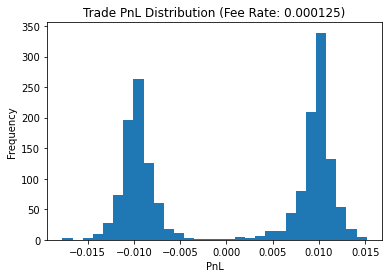

In [61]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 40, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.2,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= None,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
def core_metrics(result):
    metrics = basic_metrics(result)
    equity_curve = result.equity_curve
    trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
    trade_pnl = trades_df["pnl"]
    # pnl/equity
    trade_pnl_pct = trades_df["pnl"] / equity_curve.shift(1).reindex(trades_df["entry_time"]).values
    trades = len(trades_df)
    win_rate = metrics['win_rate']
    profit_factor = metrics['profit_factor']
    sharpe_ratio = metrics['sharpe_ratio']
    MDD = metrics['max_drawdown']
    mean_pnl_pct = trade_pnl_pct.mean()
    median_pnl_pct = trade_pnl_pct.median()
    p10_pnl_pct = trade_pnl_pct.quantile(0.1)
    p90_pnl_pct = trade_pnl_pct.quantile(0.9)
    return {
        'trades': trades,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': MDD,
        'mean_pnl_pct': mean_pnl_pct,
        'median_pnl_pct': median_pnl_pct,
        'p10_pnl_pct': p10_pnl_pct,
        'p90_pnl_pct': p90_pnl_pct,
    }
if rolling_backtest == False:
    for fee_rate in [0.000125]:
        strategy = ALBreakoutPullback50pctStrategy(params)
        cfg2 = replace(cfg, fee_rate=fee_rate)
        engine = BacktestEngine(cfg2)
        print(engine.config.fee_rate)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== Fee Rate: {fee_rate*100:.3f}% ===")
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                # print(f"{k}: {v}")
                pass
        for k, v in core_metrics(result).items():
            print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        print(trade_grouped)
        trade_pnl_pct = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

        plt.hist(trade_pnl_pct, bins=30)
        plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()

if rolling_backtest == True:
    all_metrics = {}
    for fee_rate in [0.00005]:
        for window_idx in range(len(splited_train_test_dfs)):
            print(f"=== Window {window_idx+1} ===")
            strategy = ALBreakoutPullback50pctStrategy(params)
            cfg2 = replace(cfg, fee_rate=fee_rate)
            engine = BacktestEngine(cfg2)
            print(engine.config.fee_rate)
            result = engine.run(splited_dfs[window_idx], strategy)
            metrics = basic_metrics(result)
            print(f"=== Fee Rate: {fee_rate} ===")
            for k, v in metrics.items():
                if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio', 'avg_win_held_bars', 'avg_loss_held_bars']:
                    # print(f"{k}: {v}")
                    pass
            for k, v in core_metrics(result).items():
                print(f"{k}: {v}")
                all_metrics.setdefault(k, []).append(v)
            print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
            trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
            trade_pnl = trades_df["pnl"]
            trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
            trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
            print(trade_grouped)
            # plt.hist(trade_pnl, bins=30)
            # plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
            # plt.xlabel("PnL")
            # plt.ylabel("Frequency")
            # plt.show()
    all_metrics_df = pd.DataFrame(all_metrics)
    all_metrics_df.describe() 


In [39]:
all_metrics_df

,trades,win_rate,profit_factor,sharpe_ratio,max_drawdown,mean_pnl_pct,median_pnl_pct,p10_pnl_pct,p90_pnl_pct
0,82,0.463415,0.936834,-0.912358,-0.087854,-0.000271,-0.006840,-0.010424,0.010917
1,92,0.500000,0.981123,-0.194614,-0.070780,-0.000045,0.001202,-0.010367,0.010404
2,86,0.500000,1.032129,0.384163,-0.102449,0.000216,0.001852,-0.010967,0.011236
3,64,0.531250,1.189351,1.612572,-0.079463,0.000846,0.006581,-0.010657,0.010826
4,44,0.522727,1.134732,0.633300,-0.056321,0.000653,0.004786,-0.010077,0.010977
5,46,0.500000,0.966691,-0.807145,-0.056910,-0.000121,-0.000304,-0.010907,0.011182
6,38,0.605263,1.757698,3.607350,-0.057045,0.002719,0.009904,-0.009881,0.011252
7,30,0.533333,1.210957,0.818541,-0.050632,0.000981,0.008035,-0.009986,0.010753
8,37,0.513514,1.110199,0.285928,-0.066711,0.000572,0.009008,-0.010272,0.010842
9,58,0.603448,1.674643,4.147307,-0.049963,0.002375,0.009230,-0.010362,0.011008


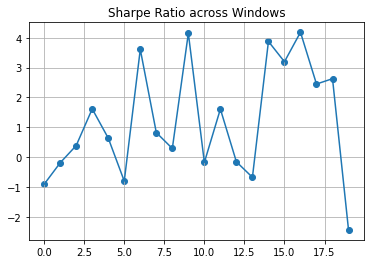

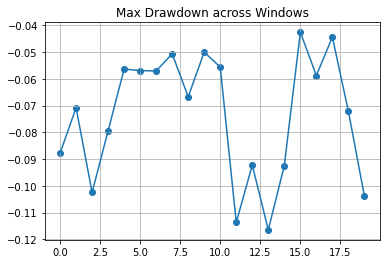

In [36]:
plt.scatter(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.plot(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.title("Sharpe Ratio across Windows")
plt.grid()
plt.show()

plt.scatter(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.plot(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.title("Max Drawdown across Windows")
plt.grid()
plt.show()

All Trades Max Loss Streaks: 7
Long Trades Max Loss Streaks: 8
Short Trades Max Loss Streaks: 9
All Trades Max Daily Cumulative Loss: -0.03236791777491328
Long Trades Max Daily Cumulative Loss: -0.028624382985239546
Long Trades Daily Cumulative < 1.5% Days: 24
Long Trades Daily Cumulative < 2% Days: 7
Short Trades Max Daily Cumulative Loss: -0.022357319596503604


C:\Users\User\AppData\Local\Temp\ipykernel_17092\3279743138.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trade_long['loss_streak'] = (trade_long['win'] == False).astype(int).groupby((trade_long['win'] != trade_long['win'].shift()).cumsum()).cumsum()
C:\Users\User\AppData\Local\Temp\ipykernel_17092\3279743138.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trade_short['loss_streak'] = (trade_short['win'] == False).astype(int).groupby((trade_short['win'] != trade_short['win'].shift()).cumsum()).cu

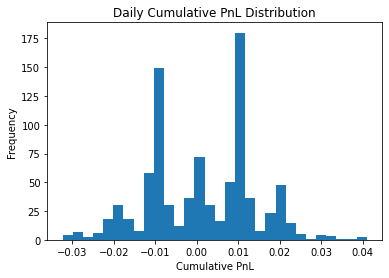

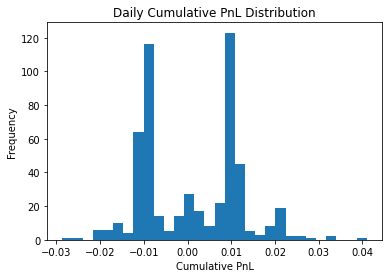

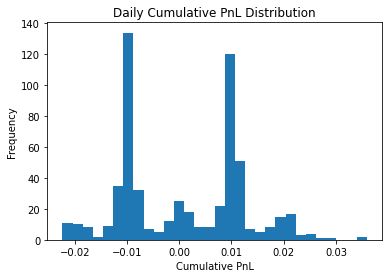

       exit_type         pnl                                       
                        mean            sum         max         min
0    ExitType.SL -147.055995 -100586.300413    4.513288 -429.387812
1  ExitType.TIME   54.969697     109.939394   76.211496   33.727898
2    ExitType.TP  149.501979  116013.535319  352.017033 -141.082195


In [28]:
trades = pd.DataFrame([t.__dict__ for t in result.trades])
trades["pnl_pct"] = trades["pnl"] / result.equity_curve.shift(1).reindex(trades["entry_time"]).values
trade_grouped = trades.groupby('exit_type').agg({'pnl': ['mean', 'sum', 'max', 'min']}).reset_index()
trades["win"] = trades["pnl"] > 0
trade_long = trades[trades['side'] == Side.LONG]
trade_short = trades[trades['side'] == Side.SHORT]
## 連敗計算
trades["loss_streak"] = (trades['win'] == False).astype(int).groupby((trades['win'] != trades['win'].shift()).cumsum()).cumsum()
trade_long['loss_streak'] = (trade_long['win'] == False).astype(int).groupby((trade_long['win'] != trade_long['win'].shift()).cumsum()).cumsum()
trade_short['loss_streak'] = (trade_short['win'] == False).astype(int).groupby((trade_short['win'] != trade_short['win'].shift()).cumsum()).cumsum()
print("All Trades Max Loss Streaks:", trades['loss_streak'].max())
print("Long Trades Max Loss Streaks:", trade_long['loss_streak'].max())
print("Short Trades Max Loss Streaks:", trade_short['loss_streak'].max())

## 日內累計虧損計算
trades['entry_date'] = trades['entry_time'].dt.date
daily_pnl = trades.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl['cum_daily_loss'] = daily_pnl['pnl_pct']
trade_long['entry_date'] = trade_long['entry_time'].dt.date
daily_pnl_long = trade_long.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_long['cum_daily_loss'] = daily_pnl_long['pnl_pct']
trade_short['entry_date'] = trade_short['entry_time'].dt.date
daily_pnl_short = trade_short.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_short['cum_daily_loss'] = daily_pnl_short['pnl_pct']
print("All Trades Max Daily Cumulative Loss:", daily_pnl['cum_daily_loss'].min())
print("Long Trades Max Daily Cumulative Loss:", daily_pnl_long['cum_daily_loss'].min())
print("Long Trades Daily Cumulative < 1.5% Days:", (daily_pnl_long['cum_daily_loss'] < -0.015).sum())
print("Long Trades Daily Cumulative < 2% Days:", (daily_pnl_long['cum_daily_loss'] < -0.02).sum())
print("Short Trades Max Daily Cumulative Loss:", daily_pnl_short['cum_daily_loss'].min())

for t in [daily_pnl, daily_pnl_long, daily_pnl_short]:
    plt.hist(t['cum_daily_loss'], bins=30)
    plt.title("Daily Cumulative PnL Distribution")
    plt.xlabel("Cumulative PnL")
    plt.ylabel("Frequency")
    plt.show()


print(trade_grouped)
# plt.hist(sort_pnls, bins=100)
# plt.show()

### Strategy Performance vs Product price

Max Drawdown: 0.1713927701141889


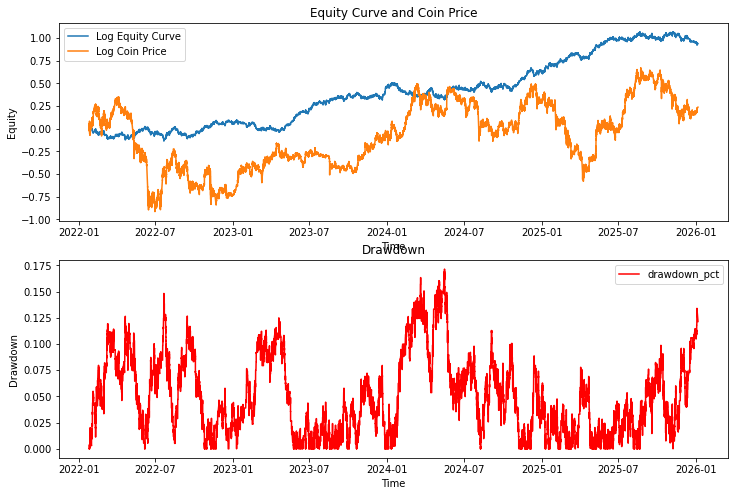

In [62]:
import matplotlib.pyplot as plt
import numpy as np
coin_curve = df.groupby(df.index).last()['close']
equity_curve = result.equity_curve
plt.figure(figsize=(12, 8))
# subplot equity curve and coin price
plt.subplot(2, 1, 1)
log_equity = np.log(equity_curve / equity_curve.iloc[0])
log_coin = np.log(coin_curve / coin_curve.iloc[0])
plt.plot(equity_curve.index, log_equity, label='Log Equity Curve')
plt.plot(coin_curve.index, log_coin, label='Log Coin Price')
drawdown_pct = (equity_curve.cummax() - equity_curve) / equity_curve.cummax()
drawdown = equity_curve.cummax() - equity_curve
max_drawdown = drawdown_pct.max()
plt.title('Equity Curve and Coin Price')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.legend()
print(f"Max Drawdown: {max_drawdown}")
## subplot drawdown
plt.subplot(2, 1, 2)
plt.plot(drawdown_pct.index, drawdown_pct.values, label='drawdown_pct', color='red')
plt.title('Drawdown')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.legend()



plt.show()

### Params Heatmap

In [57]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
import numpy as np

cfg = BacktestConfig(initial_cash=10000, fee_rate=0.000125, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 30, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.6,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side=None,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
param_name = "min_sl_range_pct"
param_values = np.arange(0.2, 1.2, 0.2)
all_metrics = {}
if rolling_backtest == False:
    for param_value in param_values:
        params = replace(params, **{param_name: param_value})
        strategy = ALBreakoutPullback50pctStrategy(params)
        engine = BacktestEngine(cfg)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== {param_name}: {param_value} ===")
        all_metrics.setdefault(param_name, []).append(param_value)
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                all_metrics.setdefault(k, []).append(v)
                print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        # trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        # trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        # print(trade_grouped)

        # plt.hist(trade_pnl, bins=30)
        # plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        # plt.xlabel("PnL")
        # plt.ylabel("Frequency")
        # plt.show()

    all_metrics_df = pd.DataFrame(all_metrics)
print(all_metrics_df)

=== min_sl_range_pct: 0.2 ===
trades: 1846.0
win_rate: 0.5390032502708559
profit_factor: 1.1656607637449823
max_drawdown: -0.18776358780252933
sharpe_ratio: 1.2409301985576953
total_days: 1440.0
final profit: 18804.05041437939
=== min_sl_range_pct: 0.4 ===
trades: 1699.0
win_rate: 0.5373749264273102
profit_factor: 1.1674925630371393
max_drawdown: -0.17339102024724387
sharpe_ratio: 1.1767814681911135
total_days: 1440.0
final profit: 16111.056388112152
=== min_sl_range_pct: 0.6000000000000001 ===
trades: 1462.0
win_rate: 0.53077975376197
profit_factor: 1.1367733869394518
max_drawdown: -0.21843533509184332
sharpe_ratio: 0.9179346578200324
total_days: 1440.0
final profit: 10193.362838171528
=== min_sl_range_pct: 0.8 ===
trades: 1195.0
win_rate: 0.5230125523012552
profit_factor: 1.1107168742937679
max_drawdown: -0.15480867097913384
sharpe_ratio: 0.6648215653126828
total_days: 1440.0
final profit: 5769.385763341721
=== min_sl_range_pct: 1.0 ===
trades: 957.0
win_rate: 0.5130616509926855
prof

In [13]:
all_metrics_df.to_excel(rf"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\pullback_ratio\tune_pullback_ratio.xlsx")

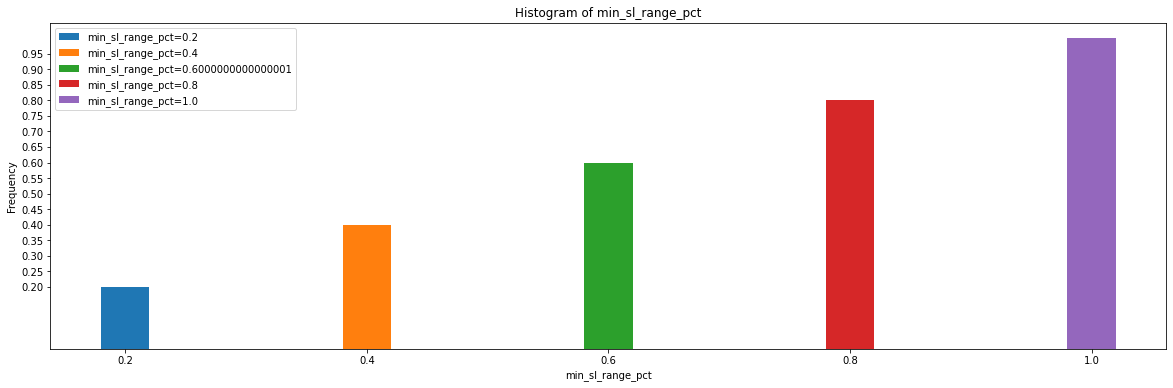

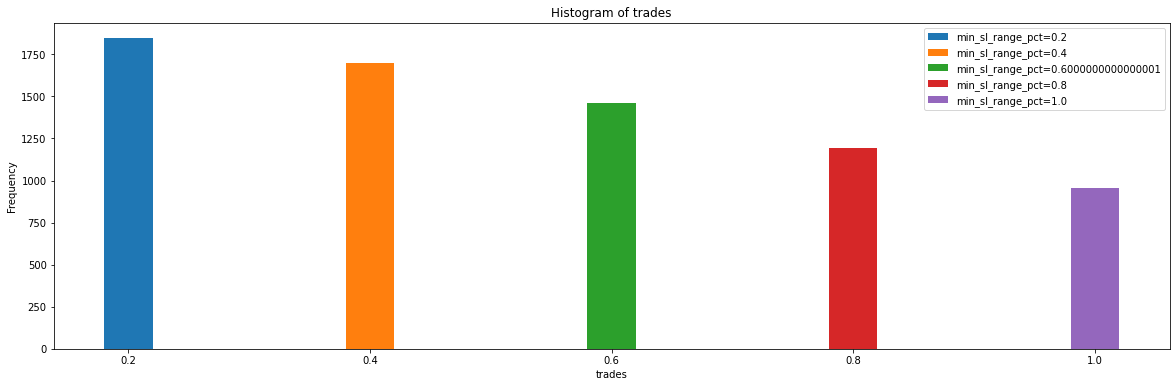

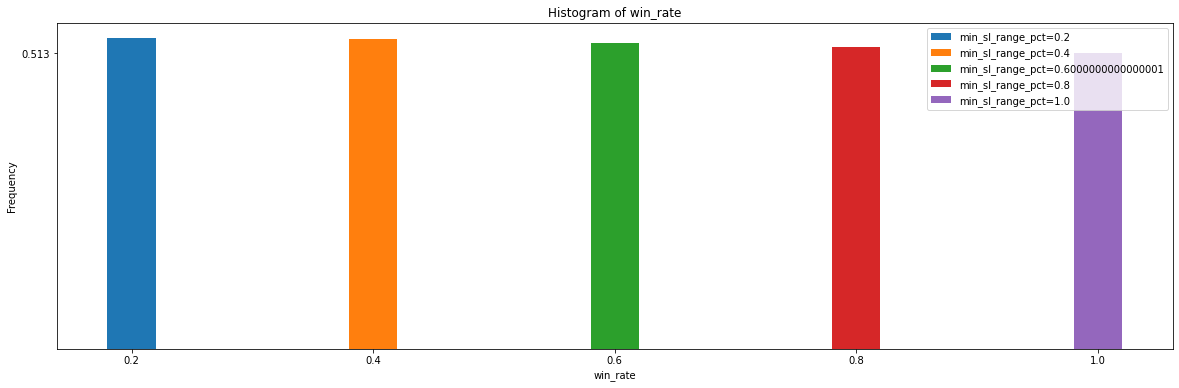

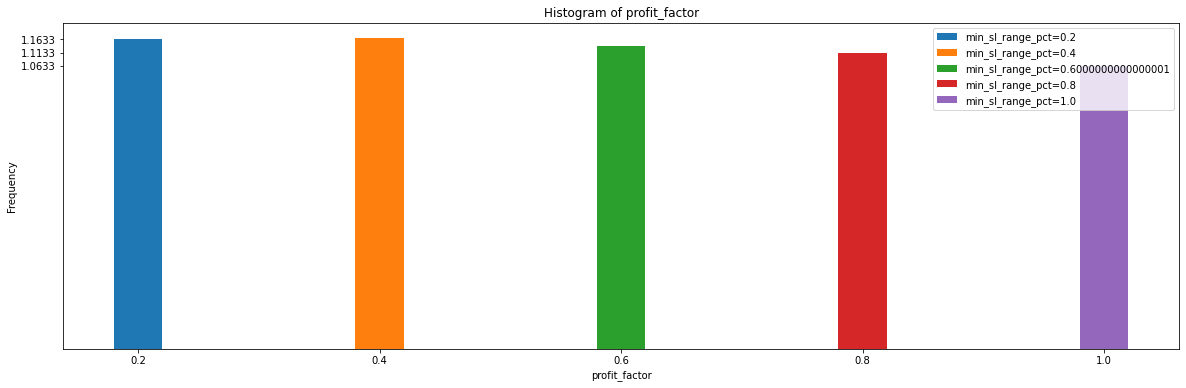

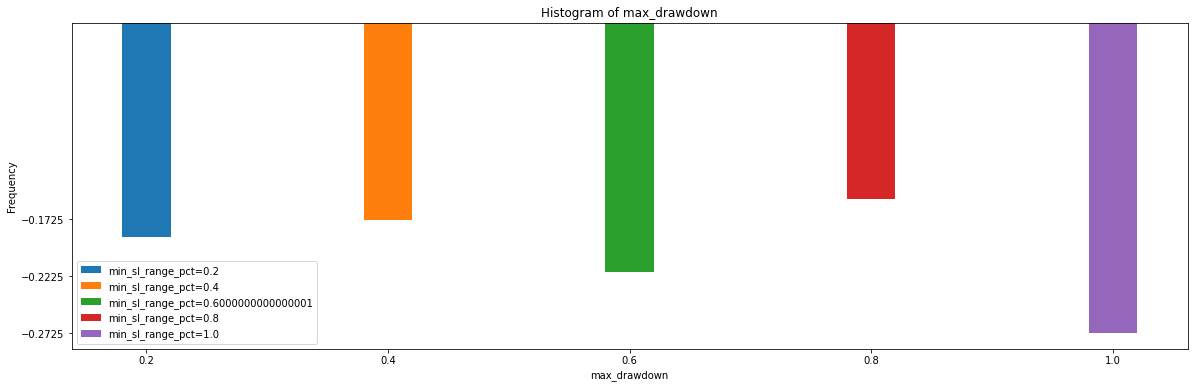

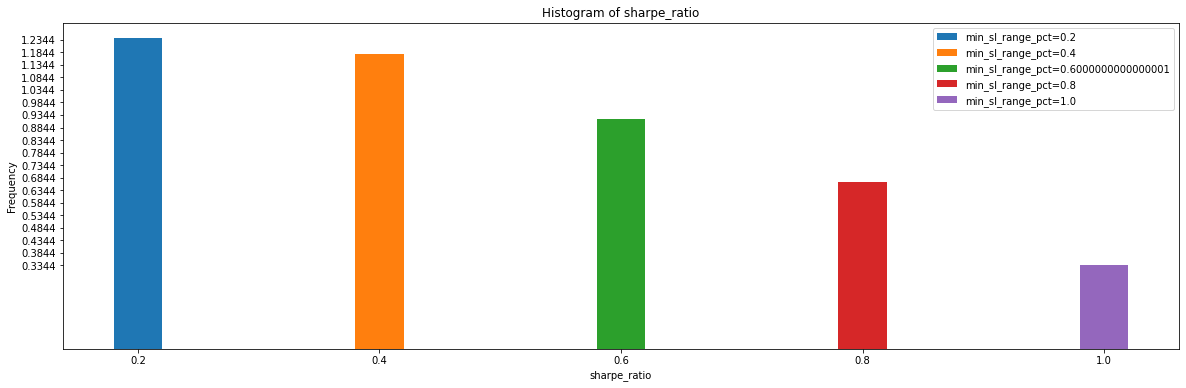

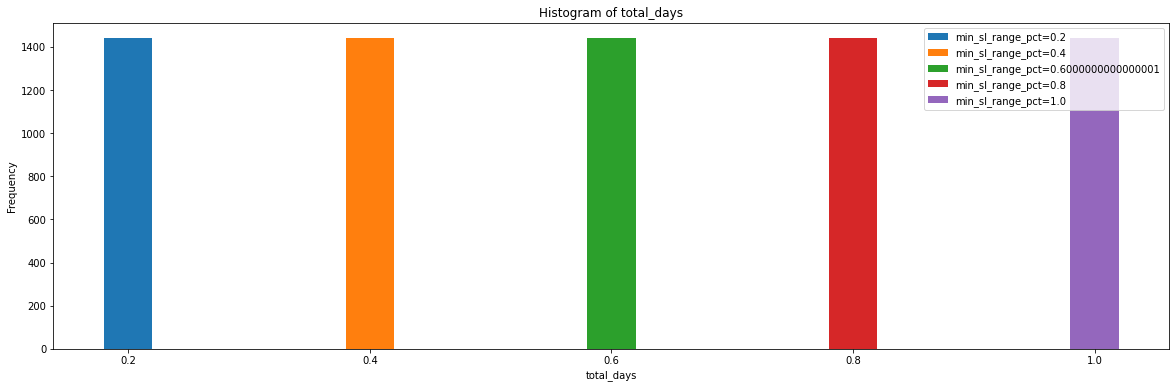

In [58]:
import matplotlib.pyplot as plt

## Draw
for metric in all_metrics_df.columns:
    plt.figure(figsize=(20, 6))
    for param_value in all_metrics_df[param_name].unique():
        subset = all_metrics_df[all_metrics_df[param_name] == param_value]
        # plot bar for each metric
        bar_x = param_value
        width = 0.04
        plt.bar(bar_x, subset[metric].values[0], width=width, label=f"{param_name}={param_value}")
    plt.title(f"Histogram of {metric}")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    if metric not in ['trades', 'total_days']:
        plt.yticks(np.arange(all_metrics_df[metric].min(), all_metrics_df[metric].max(), step=0.05))
    plt.legend()
    # plt.savefig(rf"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\pullback_ratio\{metric}_vs_{param_name}.png", dpi=300, bbox_inches='tight')
    plt.show()